<a href="https://colab.research.google.com/github/emmarquez/Analisis-de-Uso-de-Servicios-Moviles-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

  En users, las columnas `city` y `churn_date` presentan nulls.  `City` con 469 nulls (11%) y `churn_date` con 3534 nulls (88%).

  En usage, se observan nulls en las columnas `date`, `duration` y `length`; `date`: 50 nulls(0.001%), `duration`: +22k nulls (55%), `length`: +17k nulls (44%)

- Indica qué harías: ¿imputar, eliminar, ignorar?

  En users: `churn_date` se tendría que ignorar, al tener una proporción de 88%. No se eliminan pues se trata de usuarios activos e inactivos. Mientras que `city` se tendría que investigar para decidir si se imputan o se dejan como nulos.

  En usage: en `date` los nulos se podrían eliminar pues su proporción es menor al 1%. Las columnas `duration` y `lenght` se podrían imputar pero primero hay que investigar.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
cols_numericas_user= ['user_id','age']
users[cols_numericas_user].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`, sirve como identificador único que va del 10000 al 13999.
- La columna `age` cuenta con un valor mínimo de -999, un dato erróneo que tendrá que corregirse. Mediana (47) es considerablemente mayor que la media (33). La desviación estándar es muy alta (123.23), probablemente afectada por el valor mínimo.

In [ ]:
# explorar columnas numéricas de usage
cols_numericas_usage=['id','user_id','duration','length']
usage[cols_numericas_usage].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son identificadores únicos.
- Las columnas `duration` y `length` tienen valores faltantes porque cada registro corresponde a un mensaje o a una llamada. El tiempo promedio de llamadas es 5.2 min, pero hay valores altos que podrían afectar al promedio. La longitud promedio de los mensajes es de 52 caracteres, aunque podría haber outliers en los valores más altos.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()


city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` contiene seis ciudades diferentes, (Bogotá, CDMX, Medellín, Cali, GDL y MTY). Se observan algunos registros con valor `?` que deberan tratarse como datos faltantes.
- La columna `plan` tiene solamente dos categorías: Basico y Premium. Siendo el Basico el predominante en todas las ciudades.

In [ ]:

# explorar columna categórica de usage
usage['type'].value_counts()



text    22092
call    17908
Name: type, dtype: int64

- La columna `type` está estandarizada, con solo dos categorías válidas (text y call), lo que facilita su análisis y reduce la necesidad de limpieza adicional.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
Durante la revisión de los datos encontré algunos valores que necesitan limpiarse antes de comenzar el análisis.

En la tabla de usuarios, la columna `city` contiene registros con el valor `?`, que indica una ciudad desconocida, mientras que en `age` aparece el valor `-999`, utilizado para representar una edad no disponible. En ambos casos, estos valores se reemplazarán por NaN para tratarlos como datos faltantes.

Por otro lado, en la tabla de uso no se detectaron valores inválidos; sin embargo, los registros con valores 0 en la duración de llamadas y la longitud de mensajes, así como algunos valores máximos, se revisarán para confirmar que correspondan a un comportamiento real y no a errores en los datos.

En general, la calidad del conjunto de datos es buena y solo requiere algunos ajustes antes de continuar con el análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observan 40 registros del año 2026, lo que los convierte en un inválidos.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, únicamente contiene datos del 2024.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  

Después de transformar las columnas de fechas al formato `datetime`, revisé cada una de las fechas contenidas en cada una.

En `usage` todos los registros corresponden al 2024 por lo que en esta variable no se identifican problemas. Sin embargo, `reg_date` presenta 40 registros del año 2026, por lo que están fuera del rango que interesa para este análisis, es necesario revisarlos antes de continuar con el análisis. Dependiendo el contexto, se podrían corregir si es un error de captura o marcarse como faltantes si no se puede determinar la fecha correcta.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,pd.NA).fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:


# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026,'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()



count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

La verificación muestra que los valores nulos en las columnas `duration` y `length` dependen completamente de la variable `type`. Los registros de tipo call solo contienen información de duración, mientras que los de tipo text solo registran la longitud del mensaje. Por esta razón, los nulos no representan un problema de calidad de datos, sino una característica propia de la estructura del conjunto de datos. Se conservarán como valores nulos, ya que reflejan correctamente la ausencia de información que no aplica para cada tipo de registro.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes

usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage[['is_call','is_text','duration']].groupby(usage['user_id']).agg({'is_call':'sum','is_text':'sum','duration':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_call,is_text,duration
0,10000,3,7,23.70
1,10001,10,5,33.18
2,10002,2,5,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes','is_call':'cant_llamadas','duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_llamadas,cant_mensajes,cant_minutos_llamada
0,10000,3,7,23.70
1,10001,10,5,33.18
2,10002,2,5,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg,users,on='user_id')
user_profile.head(5)

,user_id,cant_llamadas,cant_mensajes,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,3,7,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,10,5,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,2,5,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,3,11,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,3,4,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:

# Resumen estadístico de las columnas numéricas
cols_numericas_up = ['cant_llamadas','cant_mensajes','cant_minutos_llamada','age']
user_profile[cols_numericas_up].describe()


,cant_llamadas,cant_mensajes,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,4.478120,5.524381,23.317054,48.124531
std,2.144238,2.358416,18.168095,17.692032
min,0.000000,0.000000,0.000000,18.000000
25%,3.000000,4.000000,11.120000,33.000000
50%,4.000000,5.000000,19.780000,47.000000
75%,6.000000,7.000000,31.415000,63.000000
max,15.000000,17.000000,155.690000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

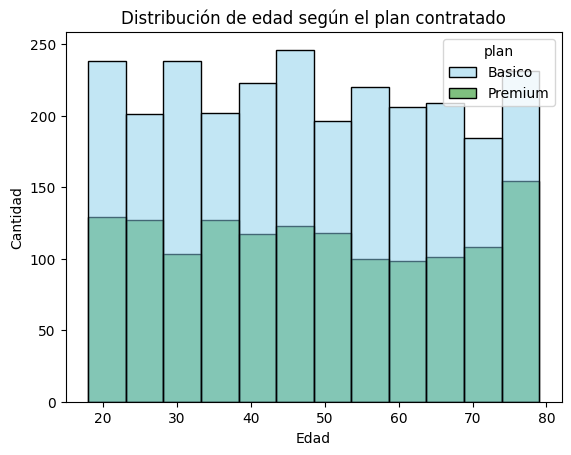

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x='age',bins=12, hue='plan',palette=['skyblue','green'])

plt.title('Distribución de edad según el plan contratado')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.show()


💡Insights:
- Distribución de edades es similar en ambos planes, con una mayor concentración de usuarios entre los 40 y 60 años. Además, el plan Básico registra una mayor cantidad de clientes en prácticamente todos los rangos de edad.


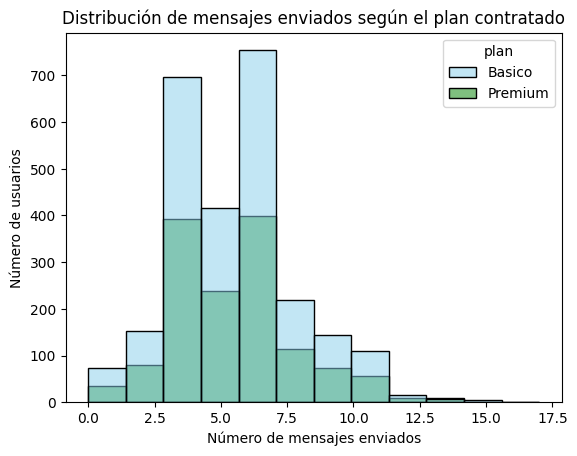

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=12, hue='plan', palette=['skyblue','green'])

plt.title('Distribución de mensajes enviados según el plan contratado')
plt.xlabel('Número de mensajes enviados')
plt.ylabel('Número de usuarios')
plt.show()

💡Insights:
- La distribución presenta un sesgo positivo, con la mayor concentración de usuarios entre 3 y 7 mensajes y una cola hacia valores más altos, lo que refleja que pocos usuarios realizan un uso intensivo del servicio. Este comportamiento es similar en ambos planes.

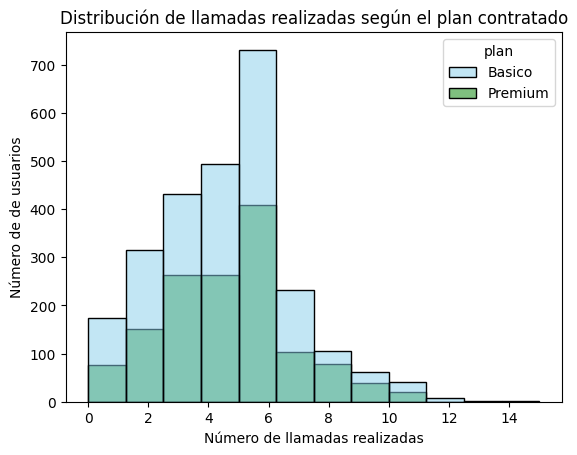

In [ ]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', bins=12, hue='plan', palette=['skyblue','green'])

plt.title('Distribución de llamadas realizadas según el plan contratado')
plt.xlabel('Número de llamadas realizadas')
plt.ylabel('Número de de usuarios')
plt.show()


💡Insights:
- La distribución del número de llamadas presenta un sesgo hacia la derecha, con la mayor concentración de usuarios realizando entre 2 y 6 llamadas. A medida que aumenta el número de llamadas, la frecuencia de usuarios disminuye, lo que indica que pocos clientes realizan un uso intensivo del servicio. Este comportamiento es similar en ambos planes.

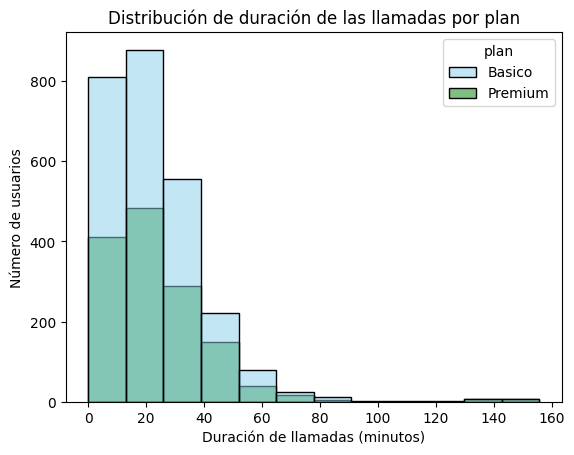

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=12, hue='plan', palette=['skyblue','green'])

plt.title('Distribución de duración de las llamadas por plan')
plt.xlabel('Duración de llamadas (minutos)')
plt.ylabel('Número de usuarios')
plt.show()


💡Insights:
- La distribución de la duración de las llamadas presenta un sesgo hacia la derecha, lo que indica que la mayoría de los usuarios realiza llamadas de corta duración, mientras que solo una pequeña proporción acumula muchos minutos. Este comportamiento es similar en ambos planes, aunque el plan Básico concentra un mayor número de usuarios.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

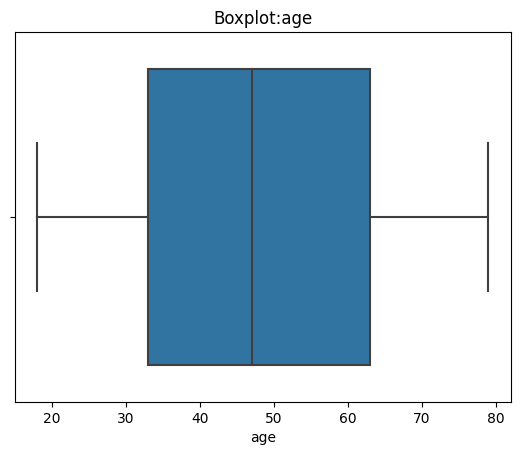

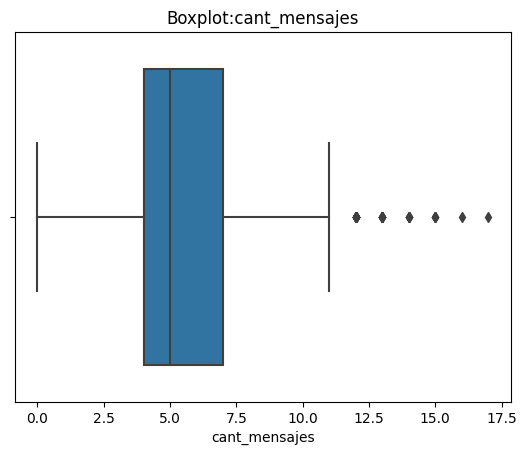

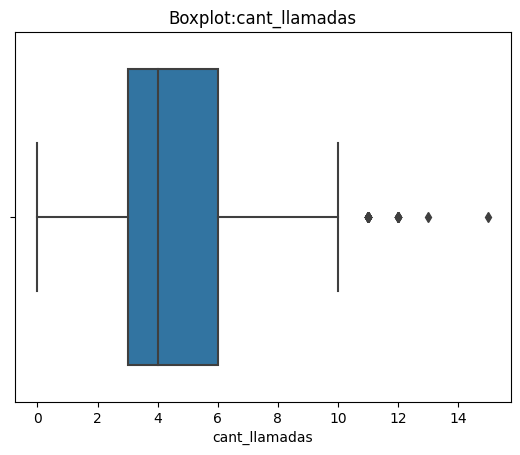

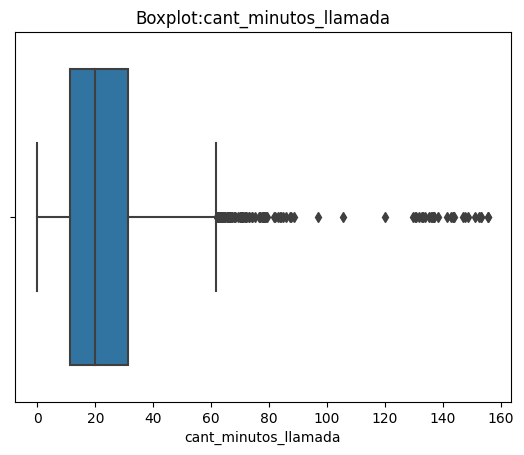

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x= col)
    plt.title(f'Boxplot:{col}')
    plt.show()

💡Insights:
- Age: La distribución de edades no presenta valores atípicos y el 50% de los usuarios tiene entre 33 y 63 años, lo que indica una población de clientes diversa en términos de edad.
- cant_mensajes: La mayoría de los usuarios envía entre 4 y 7 mensajes. Se observan algunos valores atípicos en los niveles más altos, correspondientes a usuarios con un uso más intensivo del servicio.
- cant_llamadas: El uso habitual se concentra entre 3 y 6 llamadas, aunque existen algunos usuarios que realizan un número considerablemente mayor de llamadas, identificados como valores atípicos.
- cant_minutos_llamada: La mayoría de los usuarios acumula pocos minutos de llamadas, mientras que un grupo reducido presenta consumos significativamente más altos, reflejados como valores atípicos y una distribución con sesgo hacia la derecha.

In [ ]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(col, 'Limite superior:',limite_superior)

cant_mensajes Limite superior: 11.5
cant_llamadas Limite superior: 10.5
cant_minutos_llamada Limite superior: 61.8575


In [ ]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: Se identifican algunos usuarios que superan los límites establecidos. Sin embargo, la diferencia respecto al máximo es poca y representa un uso intensivo pero real de los usuarios. Se mantienen los outliers ya que reflejan variaciones reales del uso de mensajes.
- cant_llamadas: Existen registros fuera del límite superior, pero estos corresponden a usuarios que realizan un mayor número de llamadas sin exceder valores realistas. Se mantendrán los valores pues representan un comportamiento natural de algunos usuarios.
- cant_minutos_llamada: Esta variable presenta un mayor número de valores por encima del límite y una distribución claramente sesgada a la derecha. Se mantendrán los datos pues podrían explicar distintos patrones de los usuarios y representar un segmento de clientes de alto consumo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:

# Crear columna grupo_uso
def clasificar_uso (row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if llamadas < 5 and mensajes <= 5:
        return "Bajo uso"
    elif llamadas < 10 and mensajes <= 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso,axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_llamadas,cant_mensajes,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,3,7,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,10,5,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,2,5,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Bajo uso
3,10003,3,11,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,3,4,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad (row):
    edad = row['age']

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad,axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_llamadas,cant_mensajes,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,3,7,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,10,5,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,2,5,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Bajo uso,Adulto
3,10003,3,11,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,3,4,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

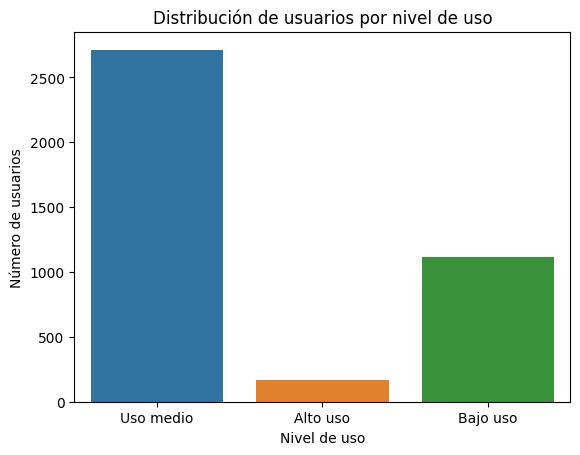

In [ ]:

# Visualización de los segmentos por uso
sns.countplot(data=user_profile,x='grupo_uso')
plt.title('Distribución de usuarios por nivel de uso')
plt.xlabel('Nivel de uso')
plt.ylabel('Número de usuarios')
plt.show()


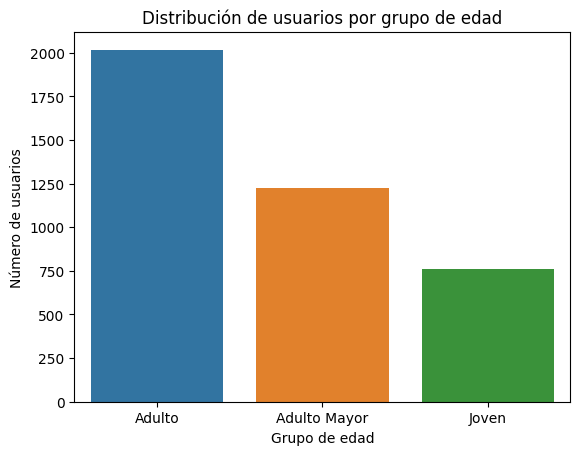

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x='grupo_edad')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En la tabla de usuarios se encontraron 96 registros con el sentinel `?`, los cuales se reemplazaron por valores nulos para evitar sesgos en los análisis geográficos. Asimismo, en la columna `age` se detectó un valor sentinel de `-999`, por lo que se sustituyó por NaN.
- En las tablas de uso y usuarios, las columnas de fecha fueron transformadas a formato de fecha. También se encontraron 40 registros con fechas del 2026, aunque el conjunto de datos solo contempla información hasta 2024, por lo que se excluyeron del análisis.


🔍 **Segmentos por Edad**
- Los adultos representan el segmento más dominante de la base de clientes, por lo que constituyen el principal público objetivo para las estrategias comerciales de ConnectaTel.
- La participación de los usuarios jóvenes es la menor entre los grupos de edad, lo que sugiere una oportunidad para atraer nuevos clientes mediante ofertas adaptadas a sus hábitos de consumo.


📊 **Segmentos por Nivel de Uso**
- La mayoría de los clientes pertenece al segmento de uso medio, lo que indica que el consumo habitual del servicio se concentra en niveles moderados y representa el principal grupo de usuarios de ConnectaTel.
- El segmento de alto uso es considerablemente más pequeño, lo que sugiere una oportunidad para diseñar ofertas o beneficios específicos que aumenten su fidelización y maximicen el valor generado por estos clientes.


➡️ Esto sugiere que, en conjunto, los resultados muestran que existen oportunidades para personalizar la oferta comercial según el perfil de los clientes. Priorizar estrategias para el segmento adulto de uso medio y desarrollar beneficios específicos para los usuarios de alto consumo podría incrementar la retención, mejorar la satisfacción del cliente y maximizar el valor generado para el negocio.


💡 **Recomendaciones**
- Segmentar la oferta comercial según el nivel de consumo, aprovechando que la mayoría de los clientes presenta un nivel de uso medio, mientras que existe un grupo reducido de usuarios con un consumo significativamente mayor. ConnectaTel podría implementar una estrategia de segmentación que ofrezca planes diferenciados según el patrón de uso: beneficios para incentivar la migración de usuarios de uso medio hacia planes de mayor valor y ofertas premium para retener a los clientes de alto consumo, quienes representan un segmento estratégico para la generación de ingresos.
- Personalizar las estrategias de marketing considerando la edad y el comportamiento de uso. Dado que la mayor parte de la base de clientes está compuesta por adultos y adultos mayores, ConnectaTel puede adaptar sus campañas y beneficios a las necesidades de estos segmentos. Al mismo tiempo, sería conveniente desarrollar ofertas específicas para atraer a usuarios jóvenes y analizar el comportamiento de los clientes con consumos atípicos para identificar oportunidades de fidelización o de creación de planes especializados.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`